# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


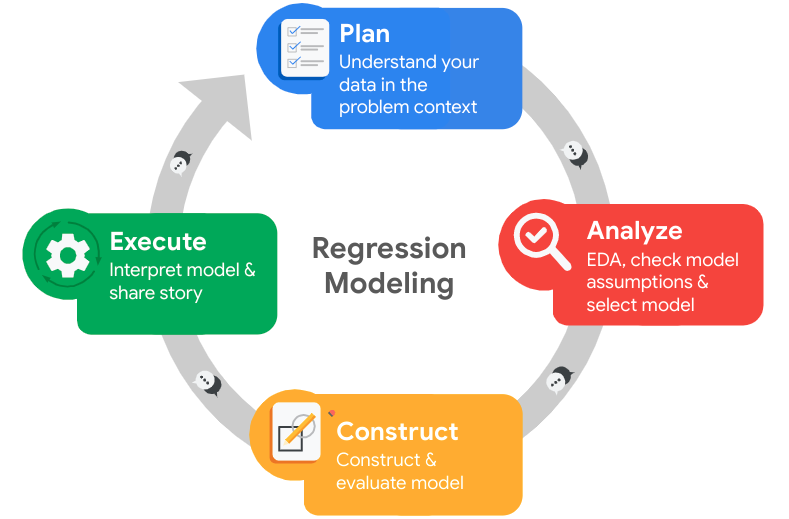

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below.

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




1. HR Team of the company.

2. We're trying to understand the behaviors that pushes employees to leave the company and build a prediction model to help the HR team in the retention process.

3. The data is mostly cleaned and doesn't require heave prior cleaning. most of the columns are numerical and the number of rows is sufficient to run a machine learning model.

4. Most of the times I rely on the documentation of the library I am using or on Generative AI models when it comes to something new.

5. The salary of each employee is encoded into categories so we're not exposing any information. Plus the model aims to help the HR team to see if someone is about to resign which can make them make a plan either to rise the compensation package or offer more days-off for them which is in their benefit. So till now there's no obvious ethical considerations.

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
### YOUR CODE HERE ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, accuracy_score, roc_auc_score, roc_curve

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [ ]:
# Gather basic information about the data
### YOUR CODE HERE ###
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [ ]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [ ]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [3]:
# Rename columns as needed
### YOUR CODE HERE ###
df0.rename(str.lower, axis ='columns', inplace= True, errors= 'raise')
df0.rename(columns={'average_montly_hours':'average_monthly_hours','time_spend_company':'tenure',},inplace=True,errors='raise')
# Display all column names after the update
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [4]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_monthly_hours,0
tenure,0
work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


### Check duplicates

Check for any duplicate entries in the data.

In [ ]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

3008

In [ ]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0.loc[df0.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [5]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df = df0.drop_duplicates(ignore_index= True)

# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
11986,0.90,0.55,3,259,10,1,0,1,management,high
11987,0.74,0.95,5,266,10,0,0,1,management,high
11988,0.85,0.54,3,185,10,0,0,1,management,high
11989,0.33,0.65,3,172,10,0,0,1,marketing,high


### Check outliers

Check for outliers in the data.

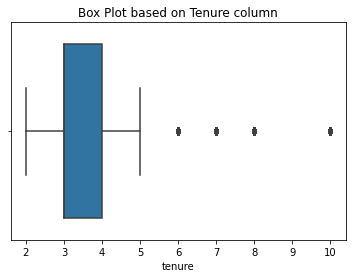

In [ ]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###
sns.boxplot(x = df['tenure'])
plt.title('Box Plot based on Tenure column')
plt.show()

In [ ]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###

(df['tenure'] > 5).sum()

824

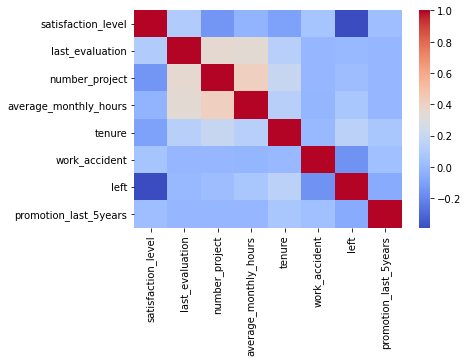

In [ ]:
sns.heatmap(data= df0.corr(method='pearson'), cmap='coolwarm')
plt.show()

Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




1. I see that there's no big correlation between features inside the data but with the dependent variable there's no big correlation as well so we will see if that will be a problem in prediction or not

2. Most of the data features are normally distributed and even the outliers is not a big deal since we will depend on tree based models.

3. Label encoding will be applied on salary since order of its categories matters, Departments will be dummy encoded. the transformations is necessary for the modeling process.

4. to find if there's any redundant data either duplicated records or high correlated columns which might affect the model predictions. Also its helpful to see which columns should be selected in the process and how predictive are they.

5. Gemini Generative AI

6. No

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [ ]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###

# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
df['left'].value_counts(normalize=True)

0    0.833959
1    0.166041
Name: left, dtype: float64

### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

In [ ]:
df[(df['promotion_last_5years'] == 1)].tenure

18        3
82        3
171       3
287       4
583       3
         ..
11985    10
11986    10
11987    10
11988    10
11989    10
Name: tenure, Length: 203, dtype: int64

# Visualizing the relationship between most important features#

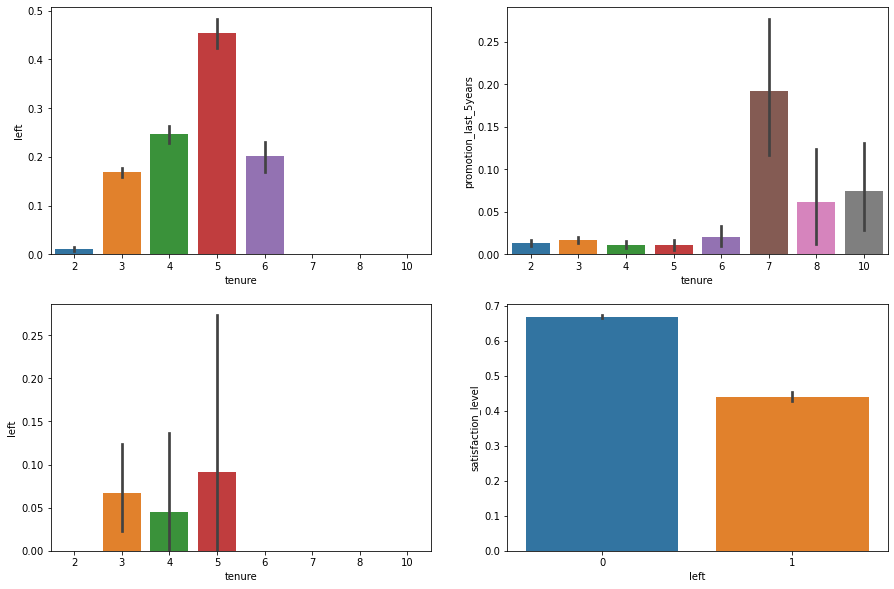

In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###
fig,axes = plt.subplots(2,2, figsize=(15,10))
sns.barplot(x = df['left'], y= df['satisfaction_level'], ax= axes[1,1])
sns.barplot(x = df['tenure'], y= df['left'], ax= axes[0,0])
sns.barplot(x = df['tenure'], y =df['promotion_last_5years'], ax = axes[0,1])
sns.barplot(x = df[(df['promotion_last_5years'] == 1)].tenure, y= df['left'], ax = axes[1,0])

# Visualizing the distribution of Department and Salary towards tenure#

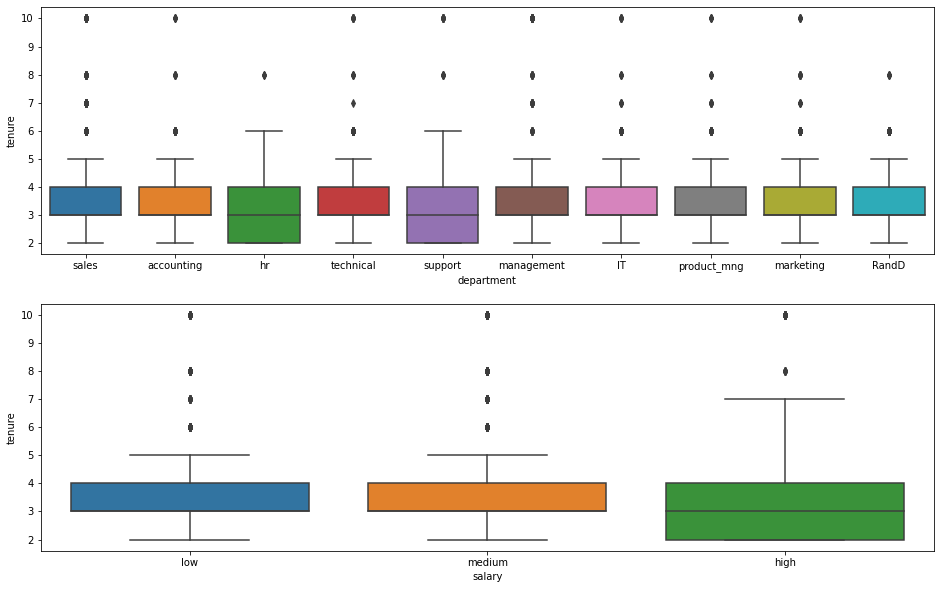

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(16,10))
sns.boxplot(x = df['department'], y = df['tenure'], ax= axes[0])
sns.boxplot(x = df['salary'], y= df['tenure'], ax = axes[1])

In [7]:
salary_map = {'low': 1, 'medium' : 2, 'high': 3}
df['salary'] = df['salary'].map(salary_map)
df_dummies = pd.get_dummies(data = df, drop_first= False)
df_dummies

/tmp/ipykernel_669/781866087.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['salary'] = df['salary'].map(salary_map)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,1,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,2,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,2,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,1,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,1,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11986,0.90,0.55,3,259,10,1,0,1,3,False,False,False,False,True,False,False,False,False,False
11987,0.74,0.95,5,266,10,0,0,1,3,False,False,False,False,True,False,False,False,False,False
11988,0.85,0.54,3,185,10,0,0,1,3,False,False,False,False,True,False,False,False,False,False
11989,0.33,0.65,3,172,10,0,0,1,3,False,False,False,False,False,True,False,False,False,False


### Insights

It seems like satisfaction level is helpful predictor. Also it appears that promotions affect the tendency for the employees to either leave or stay. it seems like employees with 5 years at the company which received no promotions at all has the highest probability to leave the company. starting from 3 years the longer they stay without a promotion the higher the chances that they are going to leave. employees with more than 6 years and got promototed has the lowest chances to leave the company

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



[Double-click to enter your responses here.]

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

Its a binary classification prediction Task, I will use XGBoost model in the process

### Identify the types of models most appropriate for this task.

Logistic Regressiom, Decision trees and tree-based models

### Modeling

Add as many cells as you need to conduct the modeling process.

In [8]:
### YOUR CODE HERE ###
x = df_dummies.drop('left', axis= 1)
y = df_dummies['left']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=0)
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size = 0.25, random_state = 0)

# Building XGBoost and RandomForest Models to compare results
model = RandomForestClassifier(random_state= 0, n_estimators= 200)
xgbcf = XGBClassifier(random_state = 0, n_estimators = 300, early_stopping_rounds = 20, eval_metric = 'logloss', tree_method = 'hist')
xgbcf.fit(x_tr,y_tr, eval_set = [(x_val,y_val)])
model.fit(x_tr,y_tr)


[0]	validation_0-logloss:0.24884
[1]	validation_0-logloss:0.19725
[2]	validation_0-logloss:0.15967
[3]	validation_0-logloss:0.13450
[4]	validation_0-logloss:0.11775
[5]	validation_0-logloss:0.10563
[6]	validation_0-logloss:0.09753
[7]	validation_0-logloss:0.09184
[8]	validation_0-logloss:0.08725
[9]	validation_0-logloss:0.08505
[10]	validation_0-logloss:0.08346
[11]	validation_0-logloss:0.08212
[12]	validation_0-logloss:0.08082
[13]	validation_0-logloss:0.07872
[14]	validation_0-logloss:0.07706
[15]	validation_0-logloss:0.07535
[16]	validation_0-logloss:0.07477
[17]	validation_0-logloss:0.07467
[18]	validation_0-logloss:0.07419
[19]	validation_0-logloss:0.07334
[20]	validation_0-logloss:0.07306
[21]	validation_0-logloss:0.07285
[22]	validation_0-logloss:0.07250
[23]	validation_0-logloss:0.07212
[24]	validation_0-logloss:0.07246
[25]	validation_0-logloss:0.07199
[26]	validation_0-logloss:0.07169
[27]	validation_0-logloss:0.07130
[28]	validation_0-logloss:0.07138
[29]	validation_0-loglos

RandomForestClassifier(n_estimators=200, random_state=0)

In [9]:
xgbcf.score(x_val,y_val), model.score(x_val, y_val)

(0.981651376146789, 0.9812343619683069)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_tr = scaler.fit_transform(x_tr)
x_val = scaler.transform(x_val)

In [10]:
import tensorflow as tf
import keras

In [20]:
keras_model = keras.models.Sequential([
    keras.layers.Dense(32, activation = 'relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(128, activation= 'relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(1, activation = 'sigmoid')
])
keras_model.compile(optimizer = 'adamw', loss = 'binary_crossentropy', metrics = ['accuracy', tf.keras.metrics.AUC(name= 'auc')])

In [21]:
history = keras_model.fit(x_tr, y_tr, validation_data= (x_val, y_val), batch_size= 100, epochs= 200, verbose = 1, callbacks= [tf.keras.callbacks.EarlyStopping(patience= 10, monitor= 'val_loss', restore_best_weights= True)])

Epoch 1/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8358 - auc: 0.6773 - loss: 0.4282 - val_accuracy: 0.8495 - val_auc: 0.8259 - val_loss: 0.3513
Epoch 2/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8522 - auc: 0.8535 - loss: 0.3302 - val_accuracy: 0.8920 - val_auc: 0.9073 - val_loss: 0.2738
Epoch 3/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8848 - auc: 0.9094 - loss: 0.2710 - val_accuracy: 0.9287 - val_auc: 0.9427 - val_loss: 0.2165
Epoch 4/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9044 - auc: 0.9332 - loss: 0.2338 - val_accuracy: 0.9466 - val_auc: 0.9537 - val_loss: 0.1829
Epoch 5/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9217 - auc: 0.9456 - loss: 0.2095 - val_accuracy: 0.9504 - val_auc: 0.9585 - val_loss: 0.1685
Epoch 6/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9280 - auc: 0.9533 - loss: 0.1942 - val_accuracy: 0.9512 - val_auc: 0.9617 - val_loss: 0.1618
Epoch 7/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms

In [26]:
ModelLoss, ModelAUC, ModelAccuracy = keras_model.evaluate(x_val, y_val)
ModelLoss,ModelAccuracy,ModelAUC

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9729 - auc: 0.9725 - loss: 0.1026


(0.10261784493923187, 0.9724820852279663, 0.9728940725326538)

In [29]:
DNN_predict = keras_model.predict(x_val)
recall_score(y_val, DNN_predict.round())

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


0.8838383838383839

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






In [ ]:
xgb_predict = xgbcf.predict(x_val)
rf_predict = model.predict(x_val)

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




#### Our focus is on Recall score (Minimizing False Negatives)

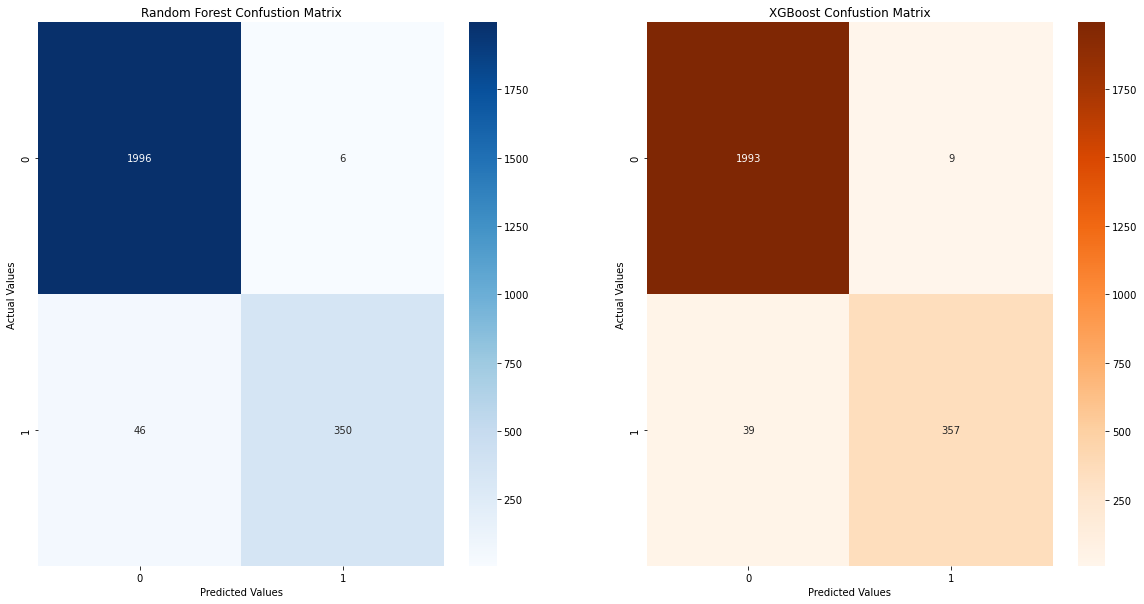

In [ ]:
fig, axes = plt.subplots(1,2, figsize= (20,10))
cm_rf = confusion_matrix(y_pred= rf_predict, y_true= y_val, labels= model.classes_)
cm_xgb = confusion_matrix(y_pred = xgb_predict, y_true = y_val, labels = xgbcf.classes_)
sns.heatmap(cm_rf, annot= True, ax= axes[0], cmap='Blues', fmt='d')
axes[0].set_title('Random Forest Confustion Matrix')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Actual Values')

sns.heatmap(cm_xgb, annot= True, ax= axes[1], cmap='Oranges', fmt='d')
axes[1].set_title('XGBoost Confustion Matrix')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Actual Values')
plt.show()

In [ ]:
print('Random Forest Recall is : {:2.2%}'.format(precision_score(y_val,rf_predict)))
print('XGBoost Recall is : {:2.2%}'.format(precision_score(y_val,xgb_predict)))

Random Forest Recall is : 98.31%
XGBoost Recall is : 97.54%


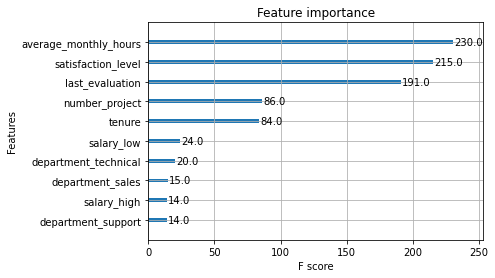

In [ ]:
import xgboost as xgb
xgb.plot_importance(xgbcf, importance_type='weight', max_num_features=10)

💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?




1. We know which features contributed the most in the prediction process (average_monthly_hours, satisfaction level and last evaluation). sure it's not obvious what relationship the columns have with the target variable. It will need further analysis.

2. from my perspective, the company should lower the loads of working hours on its employees when they face stress and those who deserve a promotion should have it ASAP since we saw it had an impact on the target variable.

3. Yes. if we apply further feature engineering or try DNN it might bring better results but for the metrics accuracy its already sufficient.

4. Seems like satisfaction comes as second in feature importance which is intuitive and straightforward, A healthy and productive environment will make employees chances for leaving much less. Also as we saw tenure employees with more than 5 years without a promotion have higher chance of leaving the company.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.